In [4]:
!pip install scikit-learn
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [7]:
from tensorflow.keras.models import load_model

model = load_model("K:/Aerial_project/notebooks/best_model.h5")

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "../data/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 215 images belonging to 2 classes.


In [10]:
predictions = model.predict(test_data)
pred_classes = (predictions > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step


In [11]:
true_classes = test_data.classes

In [12]:
cm = confusion_matrix(true_classes, pred_classes)
print(cm)

[[99 22]
 [16 78]]


In [13]:
print(classification_report(true_classes, pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       121
           1       0.78      0.83      0.80        94

    accuracy                           0.82       215
   macro avg       0.82      0.82      0.82       215
weighted avg       0.83      0.82      0.82       215



In [16]:
import pickle

with open("../models/history.pkl", "rb") as f:
    history = pickle.load(f)

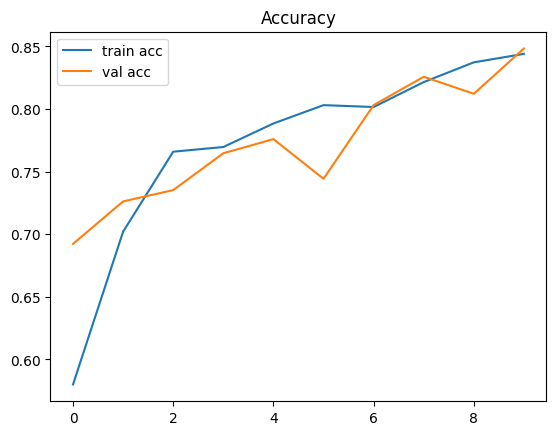

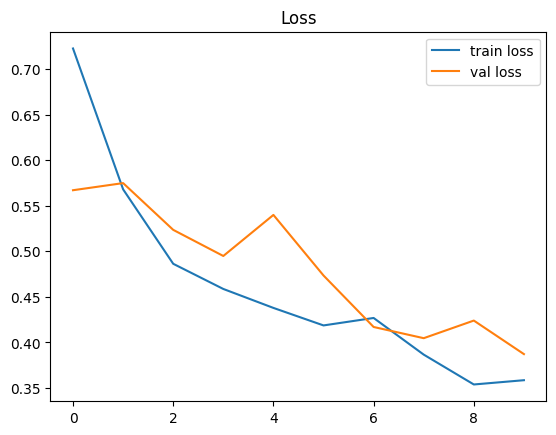

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history['accuracy'], label='train acc')
plt.plot(history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()